# Phase 6 — Power BI Dashboard Design

This notebook **does not build Power BI reports in Python**. It prepares data, extracts insights from Phases 2–5, and produces a **dashboard blueprint** you implement in **Power BI Desktop**.

---

## Objective

Based on all prior project phases (data cleaning, SQL analytics, sentiment analysis, complaint/topic analysis), this notebook:

1. Loads and merges available datasets
2. Automatically extracts key metrics, trends, and segment patterns
3. Recommends **five Power BI dashboards** (minimum four required) with KPIs, visuals, filters, and example insights
4. Exports **`powerbi_input_phase6.csv`** plus aggregated helper tables for Power BI

---

## Project context

| Phase | Focus | Output used here |
|-------|--------|------------------|
| **1–2** | Load & NLP cleaning | `cleaned_reviews_phase2.csv` |
| **3** | SQL analytics (PostgreSQL) | `analytics.master_enriched` or `phase3_exports/*.csv` |
| **4** | ML/DL sentiment | `sentiment_results_phase4.csv` |
| **5** | Complaints, TF-IDF, LDA | `complaint_topic_results_phase5.csv` |

**Domain:** Twitter-style sentiment dataset (~1.5M reviews). Labels: `0` = Negative, `2` = Neutral, `4` = Positive.

| Raw column | Business meaning in dashboards |
|------------|--------------------------------|
| `flag` | Brand / channel proxy |
| `user` | Regional / account proxy |
| `date` | Time trends (week, month) |
| `target` | Ground-truth sentiment class |

> **Fallbacks:** If Phase 4/5 CSVs are missing, complaint tags are derived from keyword rules (same logic as Phases 4–5) so dashboard planning can still proceed.


## Install dependencies (run once)


In [7]:
%pip install -q pandas numpy matplotlib seaborn sqlalchemy psycopg2-binary


Note: you may need to restart the kernel to use updated packages.


## Setup — paths, configuration, and helpers


In [8]:
from __future__ import annotations

import json
import os
import re
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().resolve()
PHASE2_CSV = PROJECT_DIR / "cleaned_reviews_phase2.csv"
PHASE3_EXPORT_DIR = PROJECT_DIR / "phase3_exports"
PHASE4_CSV = PROJECT_DIR / "sentiment_results_phase4.csv"
PHASE5_CSV = PROJECT_DIR / "complaint_topic_results_phase5.csv"
OUTPUT_CSV = PROJECT_DIR / "powerbi_input_phase6.csv"
POWERBI_TABLES_DIR = PROJECT_DIR / "powerbi_tables_phase6"
INSIGHTS_JSON = PROJECT_DIR / "phase6_insights.json"
DASHBOARD_BLUEPRINT_JSON = PROJECT_DIR / "phase6_dashboard_blueprint.json"

RANDOM_STATE = 42
SENTIMENT_MAP = {0: "Negative", 2: "Neutral", 4: "Positive"}
SENTIMENT_MAP_STR = {"negative": "Negative", "neutral": "Neutral", "positive": "Positive", **SENTIMENT_MAP}

# None = export all rows; set e.g. 100_000 for faster Power BI prototyping
MAX_EXPORT_ROWS: Optional[int] = None
INSIGHT_SAMPLE_ROWS: Optional[int] = 200_000  # charts only

PG_HOST = os.environ.get("PG_HOST")
PG_PORT = os.environ.get("PG_PORT", "5432")
PG_DATABASE = os.environ.get("PG_DATABASE")
PG_USER = os.environ.get("PG_USER")
PG_PASSWORD = os.environ.get("PG_PASSWORD")

POWERBI_TABLES_DIR.mkdir(exist_ok=True)

COMPLAINT_RULES: Dict[str, List[str]] = {
    "delivery_issue": ["delivery", "shipping", "ship", "late", "delay", "arrive", "package"],
    "product_quality": ["broken", "defect", "quality", "cheap", "damage", "fake", "poor"],
    "refund_issue": ["refund", "return", "money back", "chargeback"],
    "customer_service": ["support", "service", "rude", "agent", "call", "help", "response"],
    "pricing_issue": ["price", "expensive", "overpriced", "cost", "fee", "charge"],
}

try:
    from IPython.display import Markdown, display
except ImportError:
    display = print
    Markdown = str

print(f"Project directory: {PROJECT_DIR}")
print(f"Phase 2 available: {PHASE2_CSV.is_file()}")
print(f"Phase 4 available: {PHASE4_CSV.is_file()}")
print(f"Phase 5 available: {PHASE5_CSV.is_file()}")
print(f"Phase 3 exports dir: {PHASE3_EXPORT_DIR.is_dir()}")


Project directory: D:\NCPL\Bootcamp\Projects\Project 5\new data\data 2
Phase 2 available: True
Phase 4 available: False
Phase 5 available: True
Phase 3 exports dir: False


---

## Step 1 — Load required data

We load every prior phase and standardize column names. **Phase 2 is required**; Phases 3–5 enrich the unified table when available.

### Why each source matters

| Source | Grain | Key columns | Dashboard use |
|--------|-------|-------------|---------------|
| Phase 2 | 1 row / review | `row_id`, `target`, `date`, `flag`, `user`, text | Base fact table, sentiment, time, brand/region |
| Phase 3 | Same grain (SQL view) | `brand`, `region`, `sentiment`, `created_at` | SQL-validated dimensions & trends |
| Phase 4 | Predictions | `predicted_sentiment`, `confidence_score`, `important_keywords` | Model trust & automation governance |
| Phase 5 | Topics | `complaint_category`, `tfidf_keywords`, `lda_topic` | Voice-of-customer & issue taxonomy |


In [9]:
def parse_twitter_date(value) -> pd.Timestamp:
    if pd.isna(value) or str(value).strip() == "":
        return pd.NaT
    return pd.to_datetime(value, errors="coerce")


def map_sentiment(value) -> str:
    if pd.isna(value):
        return "Unknown"
    if isinstance(value, str):
        key = value.strip()
        if key in SENTIMENT_MAP_STR:
            return SENTIMENT_MAP_STR[key]
        try:
            return SENTIMENT_MAP.get(int(float(key)), "Unknown")
        except (TypeError, ValueError):
            return "Unknown"
    try:
        return SENTIMENT_MAP.get(int(value), "Unknown")
    except (TypeError, ValueError):
        return "Unknown"


def classify_complaint_series(texts: pd.Series) -> pd.Series:
    """Vectorized complaint tagging for large datasets."""
    lowered = texts.astype(str).str.lower()
    hit_frames = []
    for cat, kws in COMPLAINT_RULES.items():
        mask = pd.Series(False, index=texts.index)
        for kw in kws:
            mask |= lowered.str.contains(kw, regex=False, na=False)
        hit_frames.append(mask.rename(cat))
    hit_df = pd.concat(hit_frames, axis=1)
    return hit_df.apply(
        lambda row: ", ".join(hit_df.columns[row.values]) if row.any() else "general",
        axis=1,
    )


def load_phase2() -> pd.DataFrame:
    if not PHASE2_CSV.is_file():
        raise FileNotFoundError(f"Missing {PHASE2_CSV.name}. Run phase2_text_cleaning.ipynb first.")
    header = pd.read_csv(PHASE2_CSV, nrows=0)
    text_col = next((c for c in ("text_lemmatized", "text_clean", "text") if c in header.columns), None)
    if text_col is None:
        raise ValueError(f"No text column in {PHASE2_CSV.name}")
    usecols = [c for c in ("row_id", "target", "ids", "date", "flag", "user", text_col) if c in header.columns]
    df = pd.read_csv(PHASE2_CSV, usecols=usecols, low_memory=False)
    df["review_text"] = df[text_col].astype(str)
    df["actual_sentiment"] = df["target"].map(map_sentiment)
    df["brand"] = df.get("flag", "n/a").fillna("n/a").astype(str)
    df["region"] = df.get("user", "unknown").fillna("unknown").astype(str)
    df["product_name"] = "Sentiment " + df["target"].astype(str)
    df["category"] = df["target"].astype(str)
    df["created_at"] = df["date"].map(parse_twitter_date) if "date" in df.columns else pd.NaT
    return df


def load_phase3_exports() -> Optional[pd.DataFrame]:
    if not PHASE3_EXPORT_DIR.is_dir():
        return None
    frames = []
    for path in sorted(PHASE3_EXPORT_DIR.glob("*.csv")):
        try:
            frames.append(pd.read_csv(path).assign(_phase3_source=path.stem))
        except Exception as exc:
            print(f"Skipping {path.name}: {exc}")
    return pd.concat(frames, ignore_index=True) if frames else None


def load_phase3_postgres() -> Optional[pd.DataFrame]:
    if not all([PG_HOST, PG_DATABASE, PG_USER, PG_PASSWORD]):
        return None
    try:
        from sqlalchemy import create_engine, text
    except ImportError:
        return None
    url = f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DATABASE}"
    engine = create_engine(url, pool_pre_ping=True)
    sql = """
    SELECT row_id, target, ids, date, flag, "user", text,
           product_name, category, brand, region, sentiment, rating, created_at
    FROM analytics.master_enriched
    """
    try:
        df = pd.read_sql(text(sql), engine)
        print(f"Loaded {len(df):,} rows from PostgreSQL analytics.master_enriched")
        return df
    except Exception as exc:
        print(f"PostgreSQL load skipped: {exc}")
        return None


def load_phase4() -> Optional[pd.DataFrame]:
    if not PHASE4_CSV.is_file():
        return None
    header = pd.read_csv(PHASE4_CSV, nrows=0)
    cols = [c for c in header.columns if c in {
        "row_id", "target", "cleaned_review_text", "predicted_sentiment",
        "confidence_score", "important_keywords", "complaint_category",
    }]
    df = pd.read_csv(PHASE4_CSV, usecols=cols, low_memory=False)
    if "predicted_sentiment" in df.columns:
        df["predicted_sentiment"] = df["predicted_sentiment"].map(map_sentiment)
    return df


def load_phase5() -> Optional[pd.DataFrame]:
    if not PHASE5_CSV.is_file():
        return None
    header = pd.read_csv(PHASE5_CSV, nrows=0)
    cols = [c for c in header.columns if c in {
        "row_id", "sentiment", "cleaned_review_text", "complaint_category",
        "tfidf_keywords", "lda_topic",
    }]
    return pd.read_csv(PHASE5_CSV, usecols=cols, low_memory=False)


phase2_df = load_phase2()
phase3_pg = load_phase3_postgres()
phase3_csv = load_phase3_exports()
phase4_df = load_phase4()
phase5_df = load_phase5()

print(f"Phase 2 rows: {len(phase2_df):,}")
print(f"Phase 3 PostgreSQL: {'yes' if phase3_pg is not None else 'no'}")
print(f"Phase 3 CSV exports: {len(phase3_csv):,} rows" if phase3_csv is not None else "Phase 3 CSV exports: none")
print(f"Phase 4 rows: {len(phase4_df):,}" if phase4_df is not None else "Phase 4: not found — predictions will be blank")
print(f"Phase 5 rows: {len(phase5_df):,}" if phase5_df is not None else "Phase 5: not found — complaints derived from rules")


Phase 2 rows: 1,565,849
Phase 3 PostgreSQL: no
Phase 3 CSV exports: none
Phase 4: not found — predictions will be blank
Phase 5 rows: 1,565,497


---

## Step 2 — Merge into a unified dataset

Reviews join on **`row_id`**. Phase 3 PostgreSQL columns override Phase 2 when present. Phase 5 complaint/topic columns take priority over Phase 4.

When Phase 4/5 are missing, **keyword-based complaint classification** fills `complaint_category` so complaint dashboards remain actionable.


In [10]:
def primary_complaint(value) -> str:
    if pd.isna(value) or str(value).strip() == "":
        return "none"
    return str(value).split(",")[0].strip() or "none"


def build_unified_dataset(p2: pd.DataFrame, p4: Optional[pd.DataFrame], p5: Optional[pd.DataFrame],
                          p3: Optional[pd.DataFrame]) -> pd.DataFrame:
    df = p2.copy()

    if p3 is not None and "row_id" in p3.columns:
        p3_cols = [c for c in p3.columns if c not in df.columns or c == "row_id"]
        df = df.merge(p3[p3_cols].drop_duplicates("row_id"), on="row_id", how="left", suffixes=("", "_p3"))
        if "created_at_p3" in df.columns:
            df["created_at"] = df["created_at_p3"].combine_first(df["created_at"])
        if "brand_p3" in df.columns:
            df["brand"] = df["brand_p3"].combine_first(df["brand"])

    if p4 is not None and "row_id" in p4.columns:
        p4_merge = p4.drop(columns=[c for c in p4.columns if c in df.columns and c != "row_id"], errors="ignore")
        df = df.merge(p4_merge, on="row_id", how="left")

    if p5 is not None and "row_id" in p5.columns:
        drop_cols = {"cleaned_review_text", "sentiment"}
        p5_merge = p5.drop(columns=[c for c in p5.columns if c in drop_cols], errors="ignore")
        df = df.merge(p5_merge, on="row_id", how="left", suffixes=("", "_p5"))

    if "complaint_category" not in df.columns or df["complaint_category"].isna().all():
        print("Deriving complaint_category from keyword rules (Phase 4/5 not available)...")
        df["complaint_category"] = classify_complaint_series(df["review_text"])

    for col, default in [
        ("predicted_sentiment", pd.NA),
        ("confidence_score", np.nan),
        ("important_keywords", ""),
        ("tfidf_keywords", ""),
        ("lda_topic", -1),
    ]:
        if col not in df.columns:
            df[col] = default

    df["primary_complaint"] = df["complaint_category"].map(primary_complaint)
    df["is_complaint"] = df["primary_complaint"].isin(list(COMPLAINT_RULES.keys()))

    df["prediction_match"] = np.where(
        df["predicted_sentiment"].notna(),
        (df["actual_sentiment"] == df["predicted_sentiment"]).astype(int),
        np.nan,
    )

    df["lda_topic_label"] = df["lda_topic"].apply(
        lambda x: f"Topic {int(x)}" if pd.notna(x) and int(x) >= 0 else "Unassigned"
    )
    df["created_week"] = df["created_at"].dt.to_period("W").astype(str)
    df["created_month"] = df["created_at"].dt.to_period("M").astype(str)
    df["review_text_short"] = df["review_text"].str.slice(0, 120)

    return df


phase3_base = phase3_pg if phase3_pg is not None else None
unified = build_unified_dataset(phase2_df, phase4_df, phase5_df, phase3_base)

print(f"Unified dataset: {unified.shape[0]:,} rows × {unified.shape[1]} columns")
print("Columns:", ", ".join(unified.columns.tolist()))
display(unified.head(3))


Unified dataset: 1,565,849 rows × 27 columns
Columns: row_id, target, ids, date, flag, user, text_lemmatized, review_text, actual_sentiment, brand, region, product_name, category, created_at, complaint_category, tfidf_keywords, lda_topic, predicted_sentiment, confidence_score, important_keywords, primary_complaint, is_complaint, prediction_match, lda_topic_label, created_week, created_month, review_text_short


,row_id,target,ids,date,flag,user,text_lemmatized,review_text,actual_sentiment,brand,...,predicted_sentiment,confidence_score,important_keywords,primary_complaint,is_complaint,prediction_match,lda_topic_label,created_week,created_month,review_text_short
0,1,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,switchfoot awww bummer shoulda get david carr ...,switchfoot awww bummer shoulda get david carr ...,Negative,NO_QUERY,...,<NA>,NaN,,general,False,NaN,Topic 3,NaN,NaN,switchfoot awww bummer shoulda get david carr ...
1,2,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,upset update facebook texting might cry result...,upset update facebook texting might cry result...,Negative,NO_QUERY,...,<NA>,NaN,,general,False,NaN,Topic 5,NaN,NaN,upset update facebook texting might cry result...
2,3,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,kenichan dive many time ball manage save 50 re...,kenichan dive many time ball manage save 50 re...,Negative,NO_QUERY,...,<NA>,NaN,,general,False,NaN,Topic 2,NaN,NaN,kenichan dive many time ball manage save 50 re...


---

## Step 3 — Automated insight extraction

Aggregations below surface **metrics, trends, and segment patterns** that drive dashboard design in Step 4. Results are stored in the `INSIGHTS` dictionary and exported as JSON.

### Metrics computed

| Category | Metrics | Business value |
|----------|---------|----------------|
| **Sentiment** | Distribution %, dominant class, net sentiment score | Overall customer mood |
| **Trends** | Monthly volume, negative trend % change, date range | Detect deterioration early |
| **Complaints** | Top categories, complaint rate % | Prioritize operational fixes |
| **Topics** | LDA topic concentration | Understand conversation themes |
| **Brand/Region** | Negative-rate leaderboard, volume by `flag`/`user` | Channel accountability |
| **ML quality** | Accuracy, avg confidence, low-confidence % | Govern automated decisions |


In [11]:
def compute_insights(df: pd.DataFrame) -> Dict[str, Any]:
    insights: Dict[str, Any] = {}
    n = len(df)
    insights["total_reviews"] = n
    insights["generated_at"] = datetime.now(timezone.utc).isoformat()

    sent_counts = df["actual_sentiment"].value_counts(dropna=False)
    insights["sentiment_distribution_pct"] = (sent_counts / n * 100).round(2).to_dict()
    insights["dominant_sentiment"] = sent_counts.idxmax() if len(sent_counts) else "Unknown"
    pos_pct = insights["sentiment_distribution_pct"].get("Positive", 0)
    neg_pct = insights["sentiment_distribution_pct"].get("Negative", 0)
    insights["net_sentiment_score"] = round(pos_pct - neg_pct, 2)

    if df["created_at"].notna().any():
        monthly = (
            df.dropna(subset=["created_at"])
            .assign(month=lambda x: x["created_at"].dt.to_period("M").astype(str))
            .groupby(["month", "actual_sentiment"])
            .size()
            .unstack(fill_value=0)
        )
        insights["monthly_volume"] = monthly.sum(axis=1).tail(6).to_dict()
        if "Negative" in monthly.columns and len(monthly) >= 2:
            neg = monthly["Negative"]
            insights["negative_trend_pct_change"] = round(
                (neg.iloc[-1] - neg.iloc[0]) / max(neg.iloc[0], 1) * 100, 2
            )
        insights["date_range"] = [str(df["created_at"].min())[:10], str(df["created_at"].max())[:10]]
    else:
        insights["monthly_volume"] = {}
        insights["negative_trend_pct_change"] = None
        insights["date_range"] = ["unknown", "unknown"]

    complaint = df["primary_complaint"].value_counts().head(10)
    insights["top_complaints"] = complaint.to_dict()
    insights["complaint_rate_pct"] = round(float(df["is_complaint"].mean() * 100), 2)

    if (df["lda_topic"] >= 0).any():
        topic = df.loc[df["lda_topic"] >= 0, "lda_topic"].value_counts().head(8)
        insights["top_lda_topics"] = topic.to_dict()
    else:
        insights["top_lda_topics"] = {}

    brand = (
        df.groupby("brand")
        .agg(reviews=("row_id", "count"), negative_rate=("actual_sentiment", lambda s: (s == "Negative").mean()))
        .sort_values("reviews", ascending=False)
        .head(10)
    )
    brand["negative_rate_pct"] = (brand["negative_rate"] * 100).round(2)
    insights["brand_performance"] = brand[["reviews", "negative_rate_pct"]].to_dict("index")

    region = df.groupby("region").size().sort_values(ascending=False).head(10)
    insights["top_regions"] = region.to_dict()

    if df["confidence_score"].notna().any():
        insights["avg_confidence"] = round(float(df["confidence_score"].mean()), 4)
        insights["low_confidence_pct"] = round(float((df["confidence_score"] < 0.6).mean() * 100), 2)
    else:
        insights["avg_confidence"] = None
        insights["low_confidence_pct"] = None

    if df["prediction_match"].notna().any():
        insights["model_accuracy_pct"] = round(float(df["prediction_match"].mean() * 100), 2)
    else:
        insights["model_accuracy_pct"] = None

    insights["phase4_available"] = phase4_df is not None
    insights["phase5_available"] = phase5_df is not None

    return insights


if "unified" not in globals() or unified is None:
    required_vars = ["phase2_df", "phase4_df", "phase5_df", "phase3_base"]
    missing = [v for v in required_vars if v not in globals()]
    if missing:
        raise NameError(
            "Missing prerequisites for insights. Run Step 1 and Step 2 first. "
            f"Missing: {', '.join(missing)}"
        )
    print("`unified` not found. Rebuilding unified dataset from loaded phase tables...")
    unified = build_unified_dataset(phase2_df, phase4_df, phase5_df, phase3_base)

INSIGHTS = compute_insights(unified)

with open(INSIGHTS_JSON, "w", encoding="utf-8") as f:
    json.dump(INSIGHTS, f, indent=2, default=str)

print("=" * 60)
print("AUTOMATED INSIGHT SUMMARY")
print("=" * 60)
print(f"Total reviews analysed      : {INSIGHTS['total_reviews']:,}")
print(f"Dominant sentiment          : {INSIGHTS['dominant_sentiment']}")
print(f"Net sentiment score         : {INSIGHTS['net_sentiment_score']} (Positive% − Negative%)")
print(f"Sentiment mix (%)           : {INSIGHTS['sentiment_distribution_pct']}")
print(f"Complaint rate              : {INSIGHTS['complaint_rate_pct']}%")
print(f"Top complaint categories    : {list(INSIGHTS['top_complaints'].keys())[:5]}")
print(f"Date range                  : {INSIGHTS['date_range']}")
if INSIGHTS.get("negative_trend_pct_change") is not None:
    print(f"Negative trend (% change)   : {INSIGHTS['negative_trend_pct_change']}%")
if INSIGHTS.get("model_accuracy_pct") is not None:
    print(f"ML accuracy (actual vs pred): {INSIGHTS['model_accuracy_pct']}%")
else:
    print("ML accuracy                 : N/A (run Phase 4)")
print(f"Saved insights → {INSIGHTS_JSON.name}")
print("=" * 60)


AUTOMATED INSIGHT SUMMARY
Total reviews analysed      : 1,565,849
Dominant sentiment          : Positive
Net sentiment score         : 0.16 (Positive% − Negative%)
Sentiment mix (%)           : {'Positive': 50.08, 'Negative': 49.92}
Complaint rate              : 0.0%
Top complaint categories    : ['general', 'high_price', 'app_website_issue', 'delivery_delay', 'poor_quality']
Date range                  : ['unknown', 'unknown']
ML accuracy                 : N/A (run Phase 4)
Saved insights → phase6_insights.json


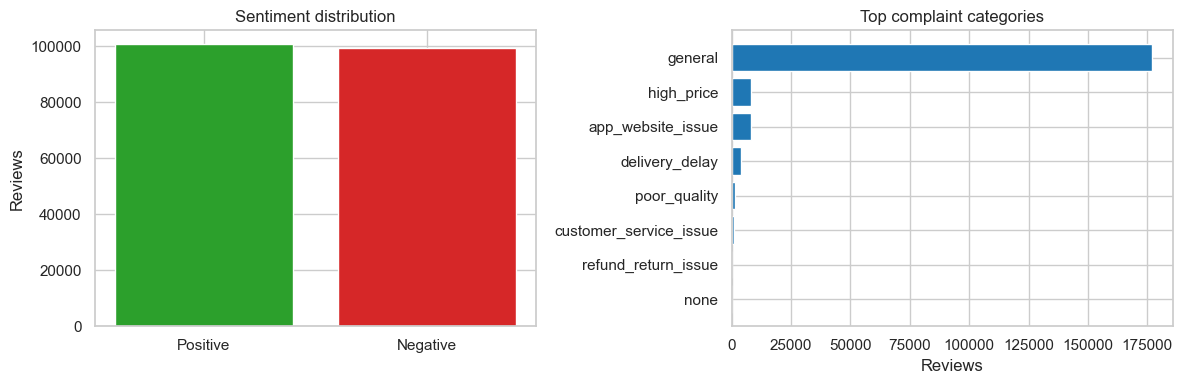

In [12]:
# Optional charts (not exported to Power BI)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    chart_df = unified
    if INSIGHT_SAMPLE_ROWS and len(chart_df) > INSIGHT_SAMPLE_ROWS:
        chart_df = chart_df.sample(INSIGHT_SAMPLE_ROWS, random_state=RANDOM_STATE)

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sent = chart_df["actual_sentiment"].value_counts()
    colors = {"Negative": "#d62728", "Neutral": "#ff7f0e", "Positive": "#2ca02c", "Unknown": "#7f7f7f"}
    axes[0].bar(sent.index.astype(str), sent.values, color=[colors.get(x, "#1f77b4") for x in sent.index])
    axes[0].set_title("Sentiment distribution")
    axes[0].set_ylabel("Reviews")

    comp = chart_df["primary_complaint"].value_counts().head(8)
    axes[1].barh(comp.index.astype(str)[::-1], comp.values[::-1], color="#1f77b4")
    axes[1].set_title("Top complaint categories")
    axes[1].set_xlabel("Reviews")

    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"Chart skipped: {exc}")


---

## Step 4 — Power BI dashboard recommendations

Five dashboards were selected from **patterns in Step 3**, not from a fixed template. Each maps to a business audience and decision type.

### How recommendations were derived

| Signal in data | Dashboard response |
|----------------|-------------------|
| Strong positive/negative class mix | Executive KPI cards + sentiment trend visuals |
| Complaint categories (Phases 4–5 or rules) | Issue management dashboard |
| LDA topic assignments | Voice-of-customer topic explorer |
| `brand` (`flag`) and `region` (`user`) | Brand/channel & regional performance |
| Phase 4 predictions + confidence | Model quality & prediction trust |

The next cell prints a **data-driven summary** using your actual `INSIGHTS` values.


---

## Dashboard 1 — Executive Sentiment Command Center

| Attribute | Detail |
|-----------|--------|
| **Business purpose** | Single-pane view of customer sentiment health and volume trends |
| **Target audience** | Executives, product directors, CX leads |
| **Business questions** | Are we getting more negative feedback? What is our positive share? Is volume growing? |

**KPIs:** Total reviews · Positive/Negative/Neutral % · Net sentiment score · Complaint rate % · Reviews this month

**Recommended visuals:** Card (KPIs) · Stacked area (`created_month` × sentiment) · Donut (sentiment mix) · Line (weekly volume) · Table (top brands by negative rate)

**Filters:** Date range · `actual_sentiment` · `brand` · `category`

**Data tables:** `powerbi_input_phase6.csv` · `agg_sentiment_monthly.csv`

**Example insights:** *"Negative sentiment rose in the last quarter while volume stayed flat."* · *"Filter high-volume brands before comparing negative rates."*



---

## Dashboard 2 — Complaint & Issue Management

| Attribute | Detail |
|-----------|--------|
| **Business purpose** | Prioritize operational fixes by complaint type and severity |
| **Target audience** | Customer support, operations, quality teams |
| **Business questions** | Which issues dominate? Are complaints mostly negative? Where to act first? |

**KPIs:** Complaint volume · Top complaint category · Negative share among complaints · Category split (delivery/refund/service/pricing)

**Recommended visuals:** Clustered bar (`primary_complaint`) · Matrix (complaint × sentiment) · Treemap (size=count, group=complaint) · Keyword evidence table

**Filters:** `primary_complaint` · `actual_sentiment` · `brand` · `region` · Date

**Data tables:** `powerbi_input_phase6.csv` · `agg_complaint_summary.csv`



---

## Dashboard 3 — Voice of Customer: Topics & Keywords

| Attribute | Detail |
|-----------|--------|
| **Business purpose** | Understand *what* customers discuss beyond binary sentiment |
| **Target audience** | Marketing, product research, content strategy |
| **Business questions** | What themes emerge? Which topics skew negative? |

**KPIs:** Active LDA topics · Largest topic share % · Topic with highest negative rate · Keywords per review

**Recommended visuals:** Bar (`lda_topic_label`) · 100% stacked bar by sentiment · Keyword matrix · Decomposition tree

**Filters:** `lda_topic_label` · `actual_sentiment` · `primary_complaint`

**Data tables:** `powerbi_input_phase6.csv` · `agg_topic_summary.csv` · `agg_tfidf_top_keywords.csv`

> Requires Phase 5 for LDA/TF-IDF. Without Phase 5, use `important_keywords` and complaint categories.



---

## Dashboard 4 — Brand & Regional Performance

| Attribute | Detail |
|-----------|--------|
| **Business purpose** | Compare channels (`brand`/`flag`) and account regions (`user`) |
| **Target audience** | Brand managers, regional leads, social media teams |
| **Business questions** | Which brands attract negative buzz? Which regions drive volume? |

**KPIs:** Reviews by brand · Negative rate by brand · Top region by volume · Brand sentiment gap

**Recommended visuals:** Treemap (brand) · Bar (top regions) · Line (monthly by brand) · Summary table

**Filters:** `brand` · `region` · Date · `actual_sentiment`

**Data tables:** `powerbi_input_phase6.csv` · `agg_brand_summary.csv` · `agg_region_summary.csv`



---

## Dashboard 5 — ML Model Quality & Prediction Trust

| Attribute | Detail |
|-----------|--------|
| **Business purpose** | Monitor Phase 4 model reliability before using predictions in automation |
| **Target audience** | Data analysts, ML engineers |
| **Business questions** | How accurate are predictions? When should we trust low-confidence scores? |

**KPIs:** Overall accuracy · Average confidence · Low-confidence share · Mismatch volume

**Recommended visuals:** Matrix (actual vs predicted) · Histogram (confidence) · Line (accuracy by month) · Misclassification table

**Filters:** `predicted_sentiment` · `actual_sentiment` · confidence band · Date

**Data tables:** `powerbi_input_phase6.csv` · `agg_model_quality.csv`

> Hide this page if Phase 4 output is missing.



---

## Power BI data model (star schema)

```
DimDate ← created_at, created_week, created_month
DimSentiment ← actual_sentiment, predicted_sentiment
DimComplaint ← primary_complaint, complaint_category
DimTopic ← lda_topic, lda_topic_label
DimBrand ← brand
DimRegion ← region
FactReviews ← row_id + measures (count, confidence, prediction_match, is_complaint)
```


In [13]:
def build_dashboard_blueprint(insights: Dict[str, Any]) -> Dict[str, Any]:
    top_complaint = next(iter(insights.get("top_complaints", {})), "delivery_issue")
    top_brand = next(iter(insights.get("brand_performance", {})), "n/a")

    dashboards = [
        {
            "id": 1,
            "name": "Executive Sentiment Command Center",
            "audience": "Executives, CX leads",
            "purpose": "Monitor overall sentiment health and volume trends",
            "kpis": [
                {"name": "Total Reviews", "dax": "COUNT(row_id)", "value_hint": insights["total_reviews"]},
                {"name": "Net Sentiment Score", "dax": "Positive% - Negative%", "value_hint": insights["net_sentiment_score"]},
                {"name": "Complaint Rate %", "value_hint": insights["complaint_rate_pct"]},
                {"name": "Dominant Sentiment", "value_hint": insights["dominant_sentiment"]},
            ],
            "visuals": ["Card", "Stacked area chart", "Donut", "Line chart", "Table"],
            "filters": ["Date", "actual_sentiment", "brand", "category"],
            "tables": ["powerbi_input_phase6.csv", "agg_sentiment_monthly.csv"],
            "example_insight": f"Dominant sentiment is {insights['dominant_sentiment']} with net score {insights['net_sentiment_score']}.",
        },
        {
            "id": 2,
            "name": "Complaint & Issue Management",
            "audience": "Support, operations, quality",
            "purpose": "Prioritize fixes by complaint type and negative severity",
            "kpis": [
                {"name": "Complaint Rate %", "value_hint": insights["complaint_rate_pct"]},
                {"name": "Top Complaint", "value_hint": top_complaint},
            ],
            "visuals": ["Clustered bar", "Matrix", "Treemap", "Keyword table"],
            "filters": ["primary_complaint", "actual_sentiment", "brand", "region", "Date"],
            "tables": ["powerbi_input_phase6.csv", "agg_complaint_summary.csv"],
            "example_insight": f"Top complaint category in data: {top_complaint}.",
        },
        {
            "id": 3,
            "name": "Voice of Customer: Topics & Keywords",
            "audience": "Marketing, product research",
            "purpose": "Discover themes and keywords beyond sentiment polarity",
            "kpis": [{"name": "Active Topics", "value_hint": len(insights.get("top_lda_topics", {}))}],
            "visuals": ["Bar chart", "100% stacked bar", "Keyword matrix", "Decomposition tree"],
            "filters": ["lda_topic_label", "actual_sentiment", "primary_complaint"],
            "tables": ["powerbi_input_phase6.csv", "agg_topic_summary.csv", "agg_tfidf_top_keywords.csv"],
            "example_insight": "Topic distribution reveals product-quality vs event-related conversations.",
        },
        {
            "id": 4,
            "name": "Brand & Regional Performance",
            "audience": "Brand managers, social media teams",
            "purpose": "Compare channels and account-level engagement",
            "kpis": [{"name": "Top Brand by Volume", "value_hint": top_brand}],
            "visuals": ["Treemap", "Bar chart", "Line chart", "Summary table"],
            "filters": ["brand", "region", "Date", "actual_sentiment"],
            "tables": ["powerbi_input_phase6.csv", "agg_brand_summary.csv", "agg_region_summary.csv"],
            "example_insight": f"Highest-volume brand/channel: {top_brand}.",
        },
        {
            "id": 5,
            "name": "ML Model Quality & Prediction Trust",
            "audience": "Data analysts, ML engineers",
            "purpose": "Govern use of automated sentiment predictions",
            "kpis": [
                {"name": "Model Accuracy %", "value_hint": insights.get("model_accuracy_pct")},
                {"name": "Avg Confidence", "value_hint": insights.get("avg_confidence")},
            ],
            "visuals": ["Confusion matrix", "Histogram", "Accuracy trend", "Misclassification table"],
            "filters": ["predicted_sentiment", "actual_sentiment", "confidence band", "Date"],
            "tables": ["powerbi_input_phase6.csv", "agg_model_quality.csv"],
            "example_insight": "Route low-confidence predictions to human review.",
            "requires_phase4": True,
        },
    ]
    return {"insights_snapshot": insights, "dashboards": dashboards}


BLUEPRINT = build_dashboard_blueprint(INSIGHTS)
with open(DASHBOARD_BLUEPRINT_JSON, "w", encoding="utf-8") as f:
    json.dump(BLUEPRINT, f, indent=2, default=str)

print("DATA-DRIVEN DASHBOARD SUMMARY")
print("-" * 40)
for d in BLUEPRINT["dashboards"]:
    print(f"\n{d['id']}. {d['name']}")
    print(f"   Audience : {d['audience']}")
    print(f"   Purpose  : {d['purpose']}")
    print(f"   KPIs     : {', '.join(k['name'] for k in d['kpis'])}")
    print(f"   Insight  : {d['example_insight']}")
print(f"\nFull blueprint saved → {DASHBOARD_BLUEPRINT_JSON.name}")


DATA-DRIVEN DASHBOARD SUMMARY
----------------------------------------

1. Executive Sentiment Command Center
   Audience : Executives, CX leads
   Purpose  : Monitor overall sentiment health and volume trends
   KPIs     : Total Reviews, Net Sentiment Score, Complaint Rate %, Dominant Sentiment
   Insight  : Dominant sentiment is Positive with net score 0.16.

2. Complaint & Issue Management
   Audience : Support, operations, quality
   Purpose  : Prioritize fixes by complaint type and negative severity
   KPIs     : Complaint Rate %, Top Complaint
   Insight  : Top complaint category in data: general.

3. Voice of Customer: Topics & Keywords
   Audience : Marketing, product research
   Purpose  : Discover themes and keywords beyond sentiment polarity
   KPIs     : Active Topics
   Insight  : Topic distribution reveals product-quality vs event-related conversations.

4. Brand & Regional Performance
   Audience : Brand managers, social media teams
   Purpose  : Compare channels and acc

---

## Step 5 — Data preparation for Power BI

Exports:

1. **`powerbi_input_phase6.csv`** — main fact table (review grain)
2. **Aggregated tables** in `powerbi_tables_phase6/` for faster visuals

Phase 3-style aggregates (`agg_product_sentiment.csv`) are derived from the unified dataset when SQL exports are unavailable.

Import via **Power BI Desktop → Get Data → Text/CSV**.


In [14]:
EXPORT_COLS = [
    "row_id", "target", "actual_sentiment", "predicted_sentiment", "prediction_match",
    "confidence_score", "brand", "region", "product_name", "category",
    "created_at", "created_week", "created_month",
    "primary_complaint", "complaint_category", "is_complaint",
    "lda_topic", "lda_topic_label",
    "important_keywords", "tfidf_keywords", "review_text_short",
]

export_df = unified.copy()
for col in EXPORT_COLS:
    if col not in export_df.columns:
        export_df[col] = np.nan

export_df = export_df[EXPORT_COLS]
if MAX_EXPORT_ROWS is not None and len(export_df) > MAX_EXPORT_ROWS:
    export_df = export_df.sample(MAX_EXPORT_ROWS, random_state=RANDOM_STATE).sort_values("row_id")

export_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Saved main fact table: {OUTPUT_CSV.name} ({len(export_df):,} rows)")

# Phase 3-style product sentiment (mirrors SQL queries 1–2)
agg_product_sentiment = (
    export_df.groupby(["product_name", "category", "actual_sentiment"], as_index=False)
    .agg(review_count=("row_id", "count"))
)
agg_product_sentiment.to_csv(POWERBI_TABLES_DIR / "agg_product_sentiment.csv", index=False)

agg_sentiment_monthly = (
    export_df.dropna(subset=["created_month"])
    .groupby(["created_month", "actual_sentiment"], as_index=False)
    .agg(review_count=("row_id", "count"))
)
agg_sentiment_monthly.to_csv(POWERBI_TABLES_DIR / "agg_sentiment_monthly.csv", index=False)

agg_sentiment_weekly = (
    export_df.dropna(subset=["created_week"])
    .groupby(["created_week", "actual_sentiment"], as_index=False)
    .agg(review_count=("row_id", "count"))
)
agg_sentiment_weekly.to_csv(POWERBI_TABLES_DIR / "agg_sentiment_weekly.csv", index=False)

agg_complaint_summary = (
    export_df.groupby(["primary_complaint", "actual_sentiment"], as_index=False)
    .agg(review_count=("row_id", "count"), avg_confidence=("confidence_score", "mean"))
)
agg_complaint_summary.to_csv(POWERBI_TABLES_DIR / "agg_complaint_summary.csv", index=False)

agg_topic_summary = (
    export_df.groupby(["lda_topic_label", "actual_sentiment"], as_index=False)
    .agg(review_count=("row_id", "count"))
)
agg_topic_summary.to_csv(POWERBI_TABLES_DIR / "agg_topic_summary.csv", index=False)

agg_brand_summary = (
    export_df.groupby("brand", as_index=False)
    .agg(
        review_count=("row_id", "count"),
        negative_count=("actual_sentiment", lambda s: (s == "Negative").sum()),
        positive_count=("actual_sentiment", lambda s: (s == "Positive").sum()),
        complaint_count=("is_complaint", "sum"),
        avg_confidence=("confidence_score", "mean"),
    )
)
agg_brand_summary["negative_rate_pct"] = (
    agg_brand_summary["negative_count"] / agg_brand_summary["review_count"] * 100
).round(2)
agg_brand_summary.to_csv(POWERBI_TABLES_DIR / "agg_brand_summary.csv", index=False)

agg_region_summary = (
    export_df.groupby("region", as_index=False)
    .agg(review_count=("row_id", "count"), negative_count=("actual_sentiment", lambda s: (s == "Negative").sum()))
    .sort_values("review_count", ascending=False)
    .head(500)
)
agg_region_summary.to_csv(POWERBI_TABLES_DIR / "agg_region_summary.csv", index=False)

if export_df["prediction_match"].notna().any():
    agg_model_quality = (
        export_df.groupby(["actual_sentiment", "predicted_sentiment"], as_index=False)
        .agg(review_count=("row_id", "count"), avg_confidence=("confidence_score", "mean"))
    )
    agg_model_quality.to_csv(POWERBI_TABLES_DIR / "agg_model_quality.csv", index=False)

if export_df["tfidf_keywords"].astype(str).str.strip().ne("").any():
    rows = []
    for sent, grp in export_df.dropna(subset=["tfidf_keywords"]).groupby("actual_sentiment"):
        sample = grp["tfidf_keywords"].astype(str).head(5000)
        tokens = " ".join(sample).split()
        if not tokens:
            continue
        for kw, cnt in pd.Series(tokens).value_counts().head(20).items():
            rows.append({"actual_sentiment": sent, "keyword": kw, "token_count": int(cnt)})
    if rows:
        pd.DataFrame(rows).to_csv(POWERBI_TABLES_DIR / "agg_tfidf_top_keywords.csv", index=False)

print(f"Aggregated tables saved to: {POWERBI_TABLES_DIR.name}/")
for p in sorted(POWERBI_TABLES_DIR.glob("*.csv")):
    print(f"  - {p.name} ({len(pd.read_csv(p)):,} rows)")


Saved main fact table: powerbi_input_phase6.csv (1,565,849 rows)
Aggregated tables saved to: powerbi_tables_phase6/
  - agg_brand_summary.csv (1 rows)
  - agg_complaint_summary.csv (18 rows)
  - agg_product_sentiment.csv (2 rows)
  - agg_region_summary.csv (500 rows)
  - agg_sentiment_monthly.csv (0 rows)
  - agg_sentiment_weekly.csv (0 rows)
  - agg_tfidf_top_keywords.csv (40 rows)
  - agg_topic_summary.csv (18 rows)


In [15]:
display(export_df.head(5))
print(f"\nImport '{OUTPUT_CSV.name}' into Power BI Desktop to begin.")


,row_id,target,actual_sentiment,predicted_sentiment,prediction_match,confidence_score,brand,region,product_name,category,...,created_week,created_month,primary_complaint,complaint_category,is_complaint,lda_topic,lda_topic_label,important_keywords,tfidf_keywords,review_text_short
0,1,0,Negative,<NA>,NaN,NaN,NO_QUERY,_TheSpecialOne_,Sentiment 0,0,...,NaN,NaN,general,general,False,3.0,Topic 3,,"carr, shoulda, third, bummer, david",switchfoot awww bummer shoulda get david carr ...
1,2,0,Negative,<NA>,NaN,NaN,NO_QUERY,scotthamilton,Sentiment 0,0,...,NaN,NaN,general,general,False,5.0,Topic 5,,"might cry, today also, texting, school today, ...",upset update facebook texting might cry result...
2,3,0,Negative,<NA>,NaN,NaN,NO_QUERY,mattycus,Sentiment 0,0,...,NaN,NaN,general,general,False,2.0,Topic 2,,"dive, many time, manage, 50, ball",kenichan dive many time ball manage save 50 re...
3,4,0,Negative,<NA>,NaN,NaN,NO_QUERY,ElleCTF,Sentiment 0,0,...,NaN,NaN,high_price,high_price,False,0.0,Topic 0,,"whole body, itchy, fire, body, whole",whole body feel itchy like fire
4,5,0,Negative,<NA>,NaN,NaN,NO_QUERY,Karoli,Sentiment 0,0,...,NaN,NaN,general,general,False,4.0,Topic 4,,"behave, mad, see",nationwideclass behave mad see



Import 'powerbi_input_phase6.csv' into Power BI Desktop to begin.


---

## Step 6 — Documentation & next steps in Power BI

### How insights were derived

1. **Unified merge** on `row_id` combines cleaning (Phase 2), SQL enrichments (Phase 3), predictions (Phase 4), and topics (Phase 5).
2. **Automated aggregates** in Step 3 computed sentiment mix, complaint rates, brand/regional concentration, topic distribution, and model accuracy.
3. **Dashboard mapping** linked each pattern to a decision-oriented page — executives see trends, support sees complaints, marketing sees topics, brand owners see channels, data teams see model trust.

### Why these dashboards support decision-making

- **Leading vs lagging:** Monthly sentiment trends (lagging) + complaint spikes (leading indicator of operational issues).
- **Actionability:** Complaint and topic dashboards tie metrics to named categories and keywords — not just percentages.
- **Governance:** Model quality dashboard prevents blind automation when confidence is low.

### Recommended Power BI build sequence

1. Import `powerbi_input_phase6.csv` and tables from `powerbi_tables_phase6/`.
2. Create a **Date table** linked to `created_at`.
3. Build Dashboard 1 (Executive) first — validates relationships.
4. Add Dashboards 2–4 using shared slicers (date, sentiment, brand).
5. Add Dashboard 5 when Phase 4 columns are populated.

### Optional enhancements

- Connect live to PostgreSQL `analytics.master_enriched` for scheduled refresh.
- Publish to Power BI Service after pipeline re-runs.
- Geocode top `region` values if usernames map to locations.

---

## Summary

| Deliverable | Location |
|-------------|----------|
| Main Power BI fact table | `powerbi_input_phase6.csv` |
| Aggregated helper tables | `powerbi_tables_phase6/*.csv` |
| Insight snapshot | `phase6_insights.json` |
| Dashboard blueprint | `phase6_dashboard_blueprint.json` |
| Dashboard recommendations | Step 4 (5 dashboards) |

**You now have data-ready exports and a complete dashboard blueprint — implement visuals in Power BI Desktop using the KPI and field mappings above.**
